### 1. 데이터 로드 및 탐색

**문제 1-1**

`pricerunner_aggregate.csv` 파일을 읽고 `Product Title` 컬럼의 상위 5개를 출력하시오.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
product_df = pd.read_csv('data/pricerunner_aggregate.csv')
product_df['Product Title'].head(5)

0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
Name: Product Title, dtype: str

**문제 1-2**

상품명이 비어 있거나 결측치인 행이 있는 경우, 해당 행은 삭제하시오.

In [4]:
product_df = product_df.dropna(subset=['Product Title'])
product_df = product_df[product_df['Product Title'] != '']

### 2. 텍스트 전처리

**문제 2-1**

모든 상품명을 소문자로 변환하고, 알파벳과 숫자를 제외한 문자는 모두 제거하여 `clean_title` 컬럼으로 저장하시오.

(힌트: 적절한 정규표현식을 사용해보세요.)

In [ ]:
# 소문자 변환
# 알파벳(a-z), 숫자(0-9), 공백만 남기고 나머지 문자 제거
# 여러 공백은 하나로 정리
product_df['clean_title'] = (
    product_df['Product Title']
    .str.lower()
    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print(product_df[['Product Title', 'clean_title']].head())

### 3. TfidfVectorizer 벡터화

**문제 3-1**

TfidfVectorizer(stop_words='english', max_features=1000)`를 사용하여 상품명을 벡터화하시오. 생성된 벡터의 크기(shape)를 출력하시오.

(힌트: TfidfVectorizer는 CountVectorizer처럼 단어를 숫자로 바꾸는 도구이지만, 단순 등장 횟수 대신 각 문서에서 단어가 얼마나 중요한지도 함께 반영한다.
즉, 여러 상품명에 공통으로 자주 등장하는 단어의 영향은 줄이고, 특정 상품명을 더 잘 구분해주는 단어에 더 높은 가중치를 준다.
여기서 stop_words='english'는 의미가 약한 영어 불용어를 제거하라는 뜻이고, max_features=1000은 중요한 단어를 최대 1000개까지만 사용하라는 뜻이다.)

In [7]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X= vectorizer.fit_transform(product_df['clean_title'])

print('벡터 shape:', X.shape)


벡터 shape: (35311, 1000)


### 4. 최적 클러스터 수 결정 (Silhouette Score)

**문제 4-1**

KMeans를 사용하여 군집 수를 2~10까지 변화시키며 군집화를 수행하고, Silhouette Score를 계산하시오.

(힌트: `silhouette_score(X, labels)` 사용)

In [8]:
silhouette_scores = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    silhouette_scores.append(score)
    print(f'k={k}, silhouette score={score: .4f}')

c:\Users\Playdata\miniconda3\envs\ai_basic_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


k=2, silhouette score= 0.8537
k=3, silhouette score= 0.8539
k=4, silhouette score= 0.8579
k=5, silhouette score= 0.8580
k=6, silhouette score= 0.8610
k=7, silhouette score= 0.8588
k=8, silhouette score= 0.8604
k=9, silhouette score= 0.8622
k=10, silhouette score= 0.8617


**문제 4-2**

각 클러스터 수에 대한 Silhouette Score를 시각화하여 최적의 클러스터 수를 선택하시오.

,k,silhouette_score
0,2,0.853715
1,3,0.853895
2,4,0.857937
3,5,0.857982
4,6,0.861044
5,7,0.858838
6,8,0.860369
7,9,0.862172
8,10,0.861676


선택된 최적 군집 수: 9
최고 Silhouette Score:  0.8622


AttributeError: module 'matplotlib.pyplot' has no attribute 'Xticks'

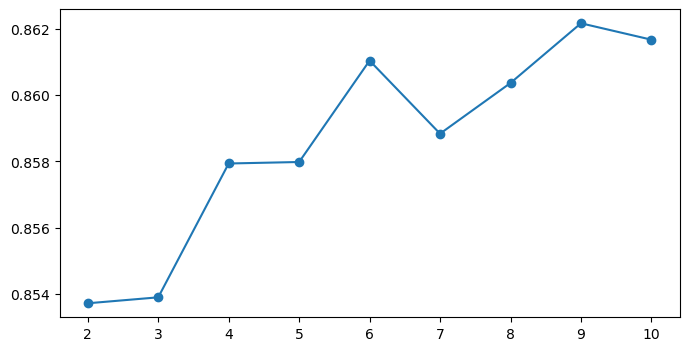

In [10]:
score_df = pd.DataFrame({
    'k' : list(k_values),
    'silhouette_score' : silhouette_scores
})

display(score_df)

best_k = score_df.loc[score_df['silhouette_score'].idxmax(),'k']
best_score = score_df['silhouette_score'].max()

print(f'선택된 최적 군집 수: {best_k}')
print(f'최고 Silhouette Score: {best_score : .4f}')

plt.figure(figsize=(8,4))
plt.plot(score_df['k'], score_df['silhouette_score'], marker='o')
plt.Xticks(list(k_values))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

### 5. KMeans 클러스터링


**문제 5-1**

선택한 최적 클러스터 수를 기준으로 KMeans를 수행하고, 결과를 `df['cluster']` 컬럼에 저장하시오.

In [ ]:
# 벡터화에 사용된 전체 단어 목록을 가져온다.
# TfidVectorizer


ceters = final_kmeans.cluster_centers_

top_n = 10

for cluster_idx in range(int(best_k)):

    top_term_indices = centers[cluster_idx].argsort()[::-1][:top_n]

    top_terms = feature_names[top_term_indices]

    print(f'클러스터 {cluster_idx}')

### 6. 2차원 시각화 (보너스)

**문제 6-1**

PCA를 사용하여 벡터를 2차원으로 축소하고, 클러스터별 색을 다르게 하여 시각화하시오.

In [ ]:
X_dense = X.toarray()

pca = PCA()


plot()
plt.title('PCA')
plt.legend(title='cluster')
plt.show()